# 02 · Data Modeling: Cleaning & Star Schema

**Goal:** understand the clean tables built by `src/build_models.py`, and learn the SQL that built them:
**JOINs, CTEs, ROW_NUMBER, CASE WHEN**.

Run `python src/build_models.py` in the terminal *before* this notebook.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd

con = duckdb.connect(str(Path("..") / "data" / "olist.duckdb"), read_only=True)
def sql(query):
    return con.sql(query).df()
print("Connected!")

Connected!


## 1. The three layers
| Layer | Schema | What happens | Analogy |
|---|---|---|---|
| Raw | `raw` | CSVs loaded untouched | ingredients as delivered |
| Staging | `staging` | rename, fix types, de-duplicate, translate | washed & chopped |
| Marts | `marts` | star schema built for analysis | the plated dish |

Why not clean the raw tables directly? Because if a cleaning rule is wrong, you can always rebuild from untouched raw data.
Every professional data team works this way.

In [2]:
sql("""
    SELECT schema_name AS layer, table_name, estimated_size AS approx_rows
    FROM duckdb_tables()
    ORDER BY CASE schema_name WHEN 'raw' THEN 1 WHEN 'staging' THEN 2 ELSE 3 END, table_name
""")

,layer,table_name,approx_rows
0,raw,category_translation,71
1,raw,customers,99441
2,raw,geolocation,1000163
3,raw,order_items,112650
4,raw,order_payments,103886
5,raw,order_reviews,99224
6,raw,orders,99441
7,raw,products,32951
8,raw,sellers,3095
9,staging,stg_customers,99441


## 2. What is a star schema?
```
                 dim_date
                    │
 dim_customers ── fct_orders           dim_products
                                            │
 dim_customers ── fct_order_items ── dim_sellers
```
- **Fact tables** (`fct_`) = *events you measure*: orders, items sold. Lots of rows, mostly numbers (revenue, delivery days).
- **Dimension tables** (`dim_`) = *descriptions you slice by*: who (customer), what (product), who sold it (seller), when (date).

A business question becomes: *"measure from a fact, sliced by a dimension"*, e.g. **revenue** (fct_order_items) **by category** (dim_products).

### Grain: what does one row mean?
| Table | Grain |
|---|---|
| fct_orders | one order |
| fct_order_items | one item within an order |
| dim_customers | one real person (`customer_unique_id`) |
| dim_products / dim_sellers | one product / seller |
| dim_date | one calendar day |

## 3. JOINs: combining tables
A JOIN matches rows from two tables using a shared column (a **key**). Let's see it on tiny made-up tables first.
`VALUES` creates a small table on the fly.

In [3]:
toy = """
    WITH customers(customer, city) AS (
        VALUES ('Asha', 'Chennai'), ('Ravi', 'Mumbai'), ('Meera', 'Delhi')
    ),
    orders(order_id, customer) AS (
        VALUES (1, 'Asha'), (2, 'Asha'), (3, 'Ravi'), (4, 'Unknown person')
    )
"""
print("INNER JOIN: only rows that match on BOTH sides")
display(sql(toy + "SELECT o.order_id, o.customer, c.city FROM orders o INNER JOIN customers c ON o.customer = c.customer"))

print("LEFT JOIN: ALL rows from the left table; NULL where the right side has no match")
display(sql(toy + "SELECT c.customer, c.city, o.order_id FROM customers c LEFT JOIN orders o ON c.customer = o.customer"))

INNER JOIN: only rows that match on BOTH sides


,order_id,customer,city
0,1,Asha,Chennai
1,2,Asha,Chennai
2,3,Ravi,Mumbai


LEFT JOIN: ALL rows from the left table; NULL where the right side has no match


,customer,city,order_id
0,Asha,Chennai,1
1,Asha,Chennai,2
2,Ravi,Mumbai,3
3,Meera,Delhi,<NA>


What to notice:
- **INNER JOIN** dropped order 4 (no matching customer) and Meera (no orders).
- **LEFT JOIN** kept Meera with `order_id = NULL`, which is how we find *customers who never ordered*.
- Asha appears **twice**, because she has 2 orders. A join repeats rows when one side has many matches.

Real example: attach the real person to each order (`stg_orders` → `stg_customers`).

In [4]:
sql("""
    SELECT o.order_id, o.customer_id, c.customer_unique_id, c.state
    FROM staging.stg_orders AS o
    JOIN staging.stg_customers AS c ON o.customer_id = c.customer_id
    LIMIT 5
""")

,order_id,customer_id,customer_unique_id,state
0,00e7ee1b050b8499577073aeb2a297a1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,SP
1,29150127e6685892b6eab3eec79f59c7,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,SP
2,b2059ed67ce144a36e2aa97d2c9e9ad2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,SP
3,951670f92359f4fe4a63112aa7306eba,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,SP
4,6b7d50bd145f6fc7f33cebabd7e49d0f,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,SP


## 4. ⚠️ The fan-out trap (the #1 SQL mistake in analytics)
What if we join orders to items **and** payments directly and add up revenue?

In [5]:
sql("""
    SELECT
        COUNT(*)                          AS rows_after_join,
        COUNT(DISTINCT o.order_id)        AS actual_orders,
        ROUND(SUM(i.price + i.freight_value) / 1e6, 2) AS revenue_millions_WRONG
    FROM staging.stg_orders o
    JOIN staging.stg_order_items i ON o.order_id = i.order_id
    JOIN staging.stg_payments   p ON o.order_id = p.order_id
""")

,rows_after_join,actual_orders,revenue_millions_WRONG
0,117601,98665,16.57


In [6]:
sql("SELECT ROUND(SUM(order_revenue) / 1e6, 2) AS revenue_millions_CORRECT FROM marts.fct_orders")

,revenue_millions_CORRECT
0,15.84


The wrong query **inflates revenue**: an order with 2 items and 2 payments becomes 4 rows, so each item is counted twice.
Nothing errors out. You just get a confidently wrong number.

**The fix (used in `fct_orders.sql`):** first aggregate items and payments to *one row per order*, **then** join.
And we added `test_revenue_reconciles` so this mistake can never slip in silently.

## 5. CTEs: `WITH ... AS (...)`
A CTE (Common Table Expression) is a **named mini-query** you can use in the next step, like a variable.
It turns one scary nested query into readable steps. Example: average order value by state, top 5.

In [7]:
sql("""
    WITH delivered_orders AS (          -- step 1: filter
        SELECT customer_state, order_revenue
        FROM marts.fct_orders
        WHERE order_status = 'delivered' AND in_analysis_window
    ),
    by_state AS (                       -- step 2: aggregate
        SELECT customer_state,
               COUNT(*)                     AS orders,
               ROUND(AVG(order_revenue), 2) AS avg_order_value
        FROM delivered_orders
        GROUP BY customer_state
    )
    SELECT *                            -- step 3: final pick
    FROM by_state
    WHERE orders >= 1000
    ORDER BY avg_order_value DESC
    LIMIT 5
""")

,customer_state,orders,avg_order_value
0,CE,1273,207.82
1,PE,1587,193.72
2,BA,3253,181.62
3,GO,1950,170.85
4,SC,3537,167.55


## 6. De-duplicating with `ROW_NUMBER()`
`ROW_NUMBER() OVER (PARTITION BY x ORDER BY y)` numbers rows **1, 2, 3… within each group of x**, sorted by y.
Keep `rn = 1` → one row per group. Let's watch it on an order that has several reviews:

In [8]:
example_order = sql("""
    SELECT order_id FROM raw.order_reviews GROUP BY order_id HAVING COUNT(*) > 1 LIMIT 1
""").order_id[0]

print("RAW: several reviews, numbered by ROW_NUMBER (newest = 1)")
display(sql(f"""
    SELECT order_id, review_score, review_answer_timestamp,
           ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY review_answer_timestamp DESC) AS rn
    FROM raw.order_reviews WHERE order_id = '{example_order}'
"""))
print("STAGING: only rn = 1 kept")
display(sql(f"SELECT order_id, review_score, review_answered_at FROM staging.stg_reviews WHERE order_id = '{example_order}'"))

RAW: several reviews, numbered by ROW_NUMBER (newest = 1)


,order_id,review_score,review_answer_timestamp,rn
0,1c308eca3f339414a92e518e2a2e5ee9,2,2017-12-31 20:25:02,1
1,1c308eca3f339414a92e518e2a2e5ee9,1,2017-12-31 20:19:14,2


STAGING: only rn = 1 kept


,order_id,review_score,review_answered_at
0,1c308eca3f339414a92e518e2a2e5ee9,2,2017-12-31 20:25:02


## 7. `CASE WHEN`: if/else inside SQL
Used to create categories. Here: bucket delivered orders by how long delivery took.

In [9]:
sql("""
    SELECT
        CASE
            WHEN delivery_days <= 7  THEN '1. within a week'
            WHEN delivery_days <= 14 THEN '2. 1-2 weeks'
            WHEN delivery_days <= 30 THEN '3. 2-4 weeks'
            ELSE                          '4. over a month'
        END                               AS delivery_speed,
        COUNT(*)                          AS orders,
        ROUND(AVG(review_score), 2)       AS avg_review
    FROM marts.fct_orders
    WHERE delivery_days IS NOT NULL
    GROUP BY delivery_speed
    ORDER BY delivery_speed
""")

,delivery_speed,orders,avg_review
0,1. within a week,30694,4.41
1,2. 1-2 weeks,37979,4.30
2,3. 2-4 weeks,23503,3.94
3,4. over a month,4294,2.20


Already a strong signal: **slower delivery → lower review scores.** Tested formally in notebook 05.

## 8. The payoff: questions become easy
With the star schema, business questions are short queries. **Revenue by category** = fact (`fct_order_items`) + dimension (`dim_products`):

,category,items_sold,revenue
0,health_beauty,9465,1412090.0
1,watches_gifts,5859,1264333.0
2,bed_bath_table,10953,1225209.0
3,sports_leisure,8431,1118257.0
4,computers_accessories,7644,1032724.0
5,furniture_decor,8160,880330.0
6,housewares,6795,758392.0
7,cool_stuff,3718,691681.0
8,auto,4140,669455.0
9,garden_tools,4268,567146.0


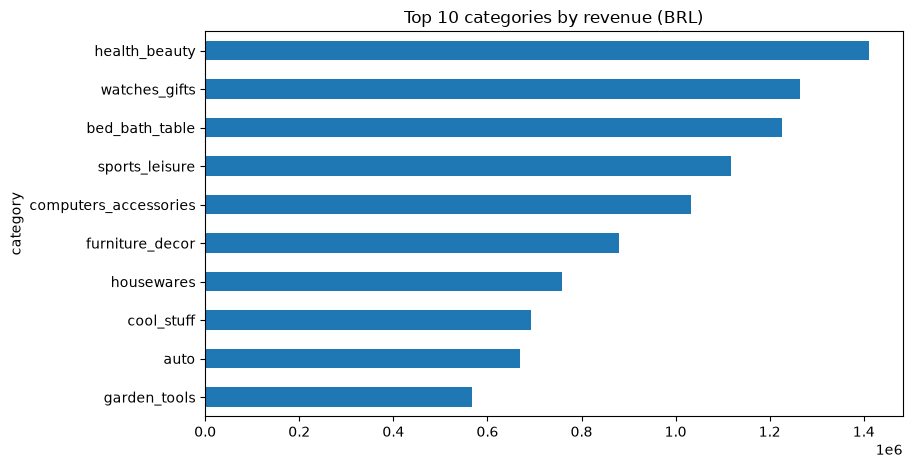

In [10]:
top_categories = sql("""
    SELECT p.category,
           COUNT(*)                          AS items_sold,
           ROUND(SUM(f.item_revenue), 0)     AS revenue
    FROM marts.fct_order_items AS f
    JOIN marts.dim_products    AS p ON f.product_id = p.product_id
    WHERE f.order_status = 'delivered'
    GROUP BY p.category
    ORDER BY revenue DESC
    LIMIT 10
""")
top_categories.plot(x="category", y="revenue", kind="barh", figsize=(9, 5), legend=False,
                    title="Top 10 categories by revenue (BRL)").invert_yaxis()
top_categories

And the headline teaser: **late vs on-time deliveries**:

In [11]:
sql("""
    SELECT CASE WHEN is_late THEN 'Late' ELSE 'On time' END AS delivery,
           COUNT(*)                                        AS orders,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_orders,
           ROUND(AVG(review_score), 2)                     AS avg_review_score
    FROM marts.fct_orders
    WHERE is_late IS NOT NULL
    GROUP BY delivery
""")

,delivery,orders,pct_orders,avg_review_score
0,Late,6534,6.8,2.27
1,On time,89936,93.2,4.29


---
## Summary
- Built a **3-layer pipeline**: raw → staging → marts, all in version-controlled SQL files.
- Designed a **star schema**: 2 fact tables + 4 dimensions, each with a clear grain.
- Handled every issue from the data quality report.
- Added **10 automated data tests** (uniqueness, no lost rows, revenue reconciliation, value ranges) that run on every build.

Next (notebook 03): revenue & growth analysis. Monthly trends, month-over-month growth with window functions, and payments.

In [12]:
con.close()